In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
import seaborn as sns
import re
import ipywidgets as widgets
import brainJ_output_analysis_v1 as bj
import warnings
from glob import glob
from functools import reduce

In [2]:
data_dir = '/Users/Documents/...'

animals = [
    'MitoPark_8wks_22341_ctrl', 'MitoPark_8wks_22340_test',
    'MitoPark_16wks_21425_ctrl', 'MitoPark_16wks_21426_test',
    'MitoPark_24wks_22842_ctrl', 'MitoPark_24wks_22841_test'
]

dir_type = 'BrainJ_output_proj_'
atlas_type = 'ABA_CCF_updated'
channel = 'C3_'
inj_site = 'SNc'
RL = ['Right', 'Left']
RL_short = ['R', 'L']
projection = ['Ipsilateral', 'Contralateral']

cell_counts = 'Total_Cells'
cell_counts_RL = [f'{cell_counts}_Right', f'{cell_counts}_Left']

average_method = 'median'
cell_threshold = 0
edge_threshold = 0.3
ylim = 5000
ylim_prop = 6

save_dir = os.path.join(data_dir, f'{dir_type}{atlas_type}', 'output')
os.makedirs(save_dir, exist_ok=True)

Atlas_Regions = pd.read_csv(os.path.join(data_dir, atlas_type, f'Atlas_Regions_{atlas_type}.csv'))
ABA_fiber_tract = pd.read_csv(os.path.join(data_dir, atlas_type, f'ABA_fiber_tracts_VS_grv_{atlas_type}.csv'))

# IDs: 374 = SNc, 749 = VTA
Atlas_Regions = Atlas_Regions[Atlas_Regions['output_id'].isin([374, 749])]

In [3]:
rgb_cols = ['red', 'green', 'blue']
col_df = Atlas_Regions.assign(
    hex_color=Atlas_Regions[rgb_cols].apply(lambda r: bj.rgb_to_hex(*r), axis=1)
)

graph_map = {
    1304: 1400, 1307: 1401, 1313: 1402, 1305: 1403, 1308: 1404,
    1310: 1405, 1312: 1406, 1306: 1407, 1309: 1408, 1311: 1409, 1314: 1410
}
col_df['graph_order_changed'] = col_df['graph_order'].replace(graph_map)
col_df = col_df[['output_id', 'hex_color', 'acronym', 'name', 'graph_order', 'graph_order_changed']]

file_dir = os.path.join(data_dir, f'{dir_type}{atlas_type}', 'data')

df_DAT_both, df_both_list, df_both_lf_list = [], [], []
df_SNc, df_SNc_lf = [], []

for a in animals:
    pattern = f'{a}_{channel}Detected_Cells_Summary.csv'
    filenames = [f for f in os.listdir(file_dir) if f.endswith(pattern)]

    df = bj.create_proj_df_for_figure_cells_both(
        data_dir, dir_type, atlas_type, filenames, ABA_fiber_tract, inj_site, col_df, cell_threshold
    )[['ID', 'Total_Cells_Both_ave', 'acronym', 'hex_color']].copy()

    total = df['Total_Cells_Both_ave'].sum()
    df['Total_Cells_Both_ave_ratio'] = df['Total_Cells_Both_ave'] / total * 100

    df_DAT_both.append(df)

    df_both, df_both_lf = bj.align_brain_region_cells_both(df, col_df)
    df_both_list.append(df_both)
    df_both_lf_list.append(df_both_lf)

    snc = df_both[0].loc[df_both[0]['acronym'] == 'SNc'].copy()
    snc['key'] = a.split('_')[3]
    snc['age'] = a.split('_')[1]
    df_SNc.append(snc)

    snc_lf = df_both_lf[0].loc[
        (df_both_lf[0]['acronym'] == 'SNc') &
        (df_both_lf[0]['variable'] == 'Total_Cells_Both_ave_ratio')
    ].copy()
    df_SNc_lf.append(snc_lf)

df_SNc = pd.concat(df_SNc, ignore_index=True)
df_SNc['key'] = df_SNc['key'].replace({'ctrl': 'Ctrl', 'test': 'MitoPark'})
df_SNc_lf = pd.concat(df_SNc_lf, ignore_index=True)

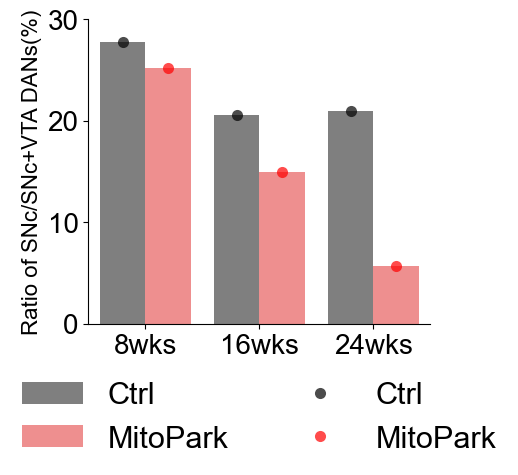

In [4]:
fig, ax = plt.subplots(figsize=(5,5))
palette = ['black', 'red']

sns.barplot(ax=ax, data=df_SNc, x='age', y='Total_Cells_Both_ave_ratio',
            alpha=0.5, hue='key', palette=palette, err_kws={'color': 'grey'})
sns.swarmplot(ax=ax, data=df_SNc, x='age', y='Total_Cells_Both_ave_ratio',
              hue='key', palette=palette, dodge=True, color='0', alpha=0.7, size=8)

ax.set_ylim(0, 30)
ax.spines[['right','top']].set_visible(False)
ax.set_ylabel('Ratio of SNc/SNc+VTA DANs(%)', fontsize=16)
ax.tick_params(labelsize=20)
ax.set_xlabel(None)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=2, frameon=False, fontsize=22)

sns.set(style='white')
fig.tight_layout()

plt.savefig(os.path.join(save_dir, '8wks_16wks_24wks_DANs_ratio_barplot.pdf'), dpi=300)
df_SNc.to_csv(os.path.join(save_dir, '8wks_16wks_24wks_DANs_ratio_barplot.csv'), index=False)